# <span style="color:blue">Product bundles Project</span>
## <span style="color:red">Introduction</span> 
#### We can see that a lot of items purchased in compatability with another items by deferent levels in the invoices.

#### We are seeking from this project to find out these relationships among items. That can help us in : 

#### Promotion recommendations, 
##### We can use it to define the product is associated with another item by which level (in how much invoice, by how much quanities). That can help to optimize the promotion efficacy. 

# <span style="color:red">The steps of the project</span>
## 1- Start with Importing needed libraries

In [3]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from scipy.stats import norm
import matplotlib.pyplot as plt 
from datetime import datetime, timedelta
from IPython.display import display, clear_output
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.cluster import KMeans 
from yellowbrick.cluster import KElbowVisualizer
from sklearn.preprocessing import StandardScaler
import pyodbc
from scipy.stats import entropy

## 2- Reading data from sources and aliases it to representative names. 

In [5]:
df_invoice = pd.read_excel("fake_sales.xlsx")

In [6]:
Sales = df_invoice.copy()


### - Adding 'disc_perc' column to sales which represent the discount percentage of each invoice and each item in the invoice

In [8]:
Sales['disc_perc'] =  (Sales['Value'] - Sales['NetValue'] ) /Sales['Value']
Sales.columns

Index(['InvoiceID', 'Date', 'SalesmanNo', 'CustomerNo', 'ItemID', 'Qty',
       'PublicPrice', 'year', 'Month', 'Value', 'NetValue',
       'PromotionsTotalPerItem', 'WAREHOUSEID', 'Inactive', 'disc_perc'],
      dtype='str')

# 
# <span style="color:blue">Market Basket Analysis</span>
## These are the steps to get a table contain the relationships between each item and the other.

In [10]:
def set_values_to_1(x):
    return 1

df = Sales.pivot_table(
    index='InvoiceID', 
    columns='ItemID',
    values = 'Qty',
    aggfunc=set_values_to_1,
    fill_value=0)
transaction = df.fillna(0)

In [11]:
transaction = transaction.reset_index()

In [12]:
transaction = transaction.drop(transaction.columns[[0]], axis=1)

In [13]:
df500 = transaction.astype('bool')

In [14]:
df500.shape

(198, 100)

In [15]:
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

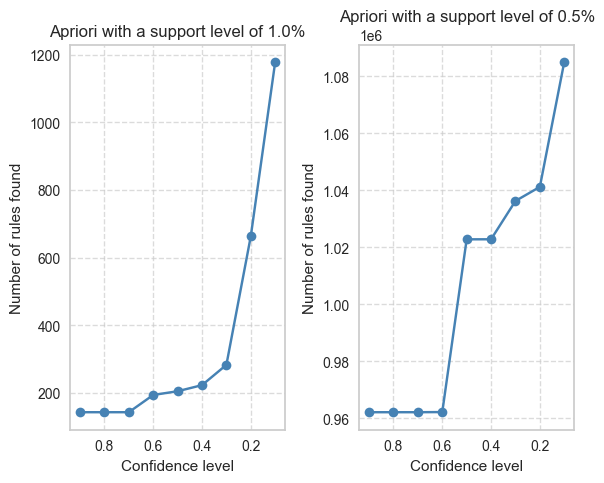

In [16]:
# Define the levels (same as your R code)
support_levels = [0.01, 0.005]
confidence_levels = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

# Create a 2x2 subplot figure
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 5))
axes = axes.flatten() # Flatten to 1D array for easy looping

for i, sup in enumerate(support_levels):
    rule_counts = []
    
    # 1. Run Apriori once for the current support level
    frequent_itemsets = apriori(df500, min_support=sup, use_colnames=True)
    
    # 2. Check how many rules exist at each confidence level
    for conf in confidence_levels:
        if not frequent_itemsets.empty:
            rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=conf)
            rule_counts.append(len(rules))
        else:
            rule_counts.append(0)
            
    # 3. Plotting on the specific subplot (ax)
    ax = axes[i]
    ax.plot(confidence_levels, rule_counts, marker='o', linestyle='-', color='steelblue')
    ax.set_title(f"Apriori with a support level of {sup*100}%")
    ax.set_xlabel("Confidence level")
    ax.set_ylabel("Number of rules found")
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.invert_xaxis() # Optional: Matches the R plot's visual flow if needed

plt.tight_layout()
plt.show()

In [17]:
# Apply Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(df500, min_support=0.01, max_len=6, use_colnames=True)
##frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold= 0.2)

In [18]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({100000}),frozenset({100003}),0.050505,0.075758,0.010101,0.20,2.640000,1.0,0.006275,1.155303,0.654255,0.086957,0.134426,0.166667
1,frozenset({100000}),frozenset({100004}),0.050505,0.065657,0.010101,0.20,3.046154,1.0,0.006785,1.167929,0.707447,0.095238,0.143784,0.176923
2,frozenset({100000}),frozenset({100048}),0.050505,0.060606,0.015152,0.30,4.950000,1.0,0.012091,1.341991,0.840426,0.157895,0.254839,0.275000
3,frozenset({100048}),frozenset({100000}),0.060606,0.050505,0.015152,0.25,4.950000,1.0,0.012091,1.265993,0.849462,0.157895,0.210106,0.275000
4,frozenset({100000}),frozenset({100055}),0.050505,0.055556,0.010101,0.20,3.600000,1.0,0.007295,1.180556,0.760638,0.105263,0.152941,0.190909


## ...............................................................................................................................................
## Here we could which represent the relationships between each item and another 
### The association rule:

#### <span style="color:red">1- Antecedent(s): </span>
##### <span style="color:blue">Meaning</span>: This column represents the item(s) that appear before the arrow (->) in the association rule. <span style="color:blue">Example</span>: {Milk, Bread}
#### <span style="color:red">2- Consequent(s):</span>
##### <span style="color:blue">Meaning</span>: This column represents the item(s) that appear after the arrow (->) in the association rule. <span style="color:blue">Example</span>: {Eggs}
#### <span style="color:red">3- Support:</span>
##### <span style="color:blue">Meaning</span>: Support is the proportion of transactions that contain the items in the rule. <span style="color:blue">Example</span>: 0.1 (10% of transactions contain {Milk, Bread, Eggs})
####  <span style="color:red">4- Confidence::</span>:
##### <span style="color:blue">Meaning</span>: Confidence is the probability that a transaction containing the antecedent(s) will also contain the consequent(s). <span style="color:blue">Example</span>: 0.8 (80% probability that a transaction with {Milk, Bread} also contains {Eggs})
#### <span style="color:red">5- Lift:</span>
##### <span style="color:blue">Meaning</span>: Lift measures how much more likely the consequent(s) are in the presence of the antecedent(s) compared to their individual probabilities. <span style="color:blue">Example</span>: 1.2 (Consequent(s) are 1.2 times more likely to be bought when antecedent(s) are present)
#### <span style="color:red">6- Leverage:</span>
##### <span style="color:blue">Meaning</span>: Leverage measures the difference between the observed frequency of the antecedent(s) and consequent(s) appearing together and the frequency expected if they were independent. <span style="color:blue">Example</span>: 0.02 (2% more occurrences of {Milk, Bread, Eggs} together than expected if independent)


In [20]:
rules.antecedents.nunique()

234

In [21]:
rules['length_ant'] = rules['antecedents'].apply(lambda x: len(x))
rules['length_cons'] = rules['consequents'].apply(lambda x: len(x))

In [22]:
rules.sort_values(by='lift', ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,length_ant,length_cons
635,"frozenset({100012, 100006})","frozenset({100011, 100036})",0.010101,0.010101,0.010101,1.0,99.0,1.0,0.009999,inf,1.0,1.0,1.0,1.0,2,2
627,"frozenset({100084, 100078})","frozenset({100056, 100004})",0.010101,0.010101,0.010101,1.0,99.0,1.0,0.009999,inf,1.0,1.0,1.0,1.0,2,2
637,"frozenset({100011, 100006})","frozenset({100036, 100012})",0.010101,0.010101,0.010101,1.0,99.0,1.0,0.009999,inf,1.0,1.0,1.0,1.0,2,2
636,"frozenset({100011, 100036})","frozenset({100012, 100006})",0.010101,0.010101,0.010101,1.0,99.0,1.0,0.009999,inf,1.0,1.0,1.0,1.0,2,2
622,"frozenset({100056, 100004})","frozenset({100084, 100078})",0.010101,0.010101,0.010101,1.0,99.0,1.0,0.009999,inf,1.0,1.0,1.0,1.0,2,2


In [23]:
rules.shape

(663, 16)

In [24]:
 Sales['InvoiceMonth'] = pd.to_datetime(Sales[['year', 'Month']].assign(day=1), format="%d/%m/%Y")

# <span style="color:blue">Creating functions:</span>
## To Facilitate all steps to get most associated products, most common promotion slices between 2 products
## ......................................................................................................................................
## 1- We are creating a function 'bst_products()' to get the most associated products to the product we select.

In [26]:
Sales.columns

Index(['InvoiceID', 'Date', 'SalesmanNo', 'CustomerNo', 'ItemID', 'Qty',
       'PublicPrice', 'year', 'Month', 'Value', 'NetValue',
       'PromotionsTotalPerItem', 'WAREHOUSEID', 'Inactive', 'disc_perc',
       'InvoiceMonth'],
      dtype='str')

In [27]:
def bst_products(product_id):
    # 1. Vectorized filtering of association rules
    # We only care about rules where the product_id is in the antecedents
    mask = rules['antecedents'].apply(lambda x: product_id in x)
    relevant_rules = rules[mask].copy()
    
    if relevant_rules.empty:
        return pd.DataFrame()

    # Extract the first item from each consequent set
    relevant_rules['recommendation_list'] = relevant_rules['consequents'].apply(lambda x: list(x)[0])
    
    # 2. Calculate metrics using vectorized math instead of repeated lookups
    total_rows = df500.shape[0]
    relevant_rules['no_shared_invoices'] = relevant_rules['support'] * total_rows
    relevant_rules['no_shared_invoices_per_month'] = relevant_rules['no_shared_invoices'] / 11
    relevant_rules['confidence_pct'] = relevant_rules['confidence'] * 100

    # 3. Merge with item info in one go (Replacement for the 'y' loop lookups)
    result = relevant_rules.fillna(0)

    # 4. Efficient customer overlap calculation
    # Only check customers who bought the target product_id
    target_customers = Sales[Sales['ItemID'] == product_id]['CustomerNo'].unique()
    potential_sales = Sales[Sales['CustomerNo'].isin(target_customers)]
    
    # Create a mapping of how many shared customers each recommended product has
    customer_counts = (
        potential_sales[potential_sales['ItemID'] != product_id]
        .groupby('ItemID')['CustomerNo']
        .nunique()
    )
    result['no_cust'] = result['recommendation_list'].map(customer_counts).fillna(0)

    # 5. Final Sorting and Cleanup
    result = (result.sort_values(by='no_shared_invoices_per_month', ascending=False).head(20)
                    .sort_values(by='confidence_pct', ascending=False).head(10))
    
    # Select and rename columns to match your desired output
    final_cols = {
        'recommendation_list': 'recommendation_list',
        'no_shared_invoices_per_month': 'no_shared_invoices_per_month',
        'no_shared_invoices': 'no_shared_invoices',
        'confidence_pct': 'confidence',
        'no_cust': 'no_cust'
    }
    
    return result[list(final_cols.keys())].rename(columns=final_cols)

In [28]:
bst_products(100044)

,recommendation_list,no_shared_invoices_per_month,no_shared_invoices,confidence,no_cust
496,100059,0.181818,2.0,100.000000,4.0
529,100068,0.181818,2.0,100.000000,3.0
531,100025,0.181818,2.0,100.000000,2.0
569,100092,0.181818,2.0,100.000000,0.0
571,100091,0.181818,2.0,100.000000,1.0
497,100012,0.181818,2.0,66.666667,3.0
269,100059,0.272727,3.0,27.272727,4.0
271,100077,0.272727,3.0,27.272727,2.0
273,100088,0.272727,3.0,27.272727,4.0
